# Campaign 16 manual split audit

This notebook reproduces the w013 closed-ring supervision used by campaigns 15 and 16, partitions it with the hand-authored training mask, and renders a full-scroll audit view.

Color interpretation:

- **red**: training ink
- **yellow**: training papyrus ring negative
- **blue**: validation ink
- **green**: validation papyrus ring negative
- **black**: unused

The prompt's second “training set ink” entry is interpreted as validation ink.

In [1]:
from pathlib import Path

import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "old":
    ROOT = ROOT.parent

SCROLL = "20240304141531"
TILE = 16
TARGET_UNIT = 8
MULTITILE_GRID = 4
MULTITILE_STEP = 16
POS_ONLY = True
CLOSE_R, GAP_R, SHELL_R = 3, 3, 2
SAVE_PNG = True


def read_binary(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    return image > 0


eroded = read_binary(ROOT / "eroded_inklabels" / f"{SCROLL}.png")
papyrus = read_binary(ROOT / "masks" / f"{SCROLL}.png")
manual_raw = read_binary(ROOT / "train_masks" / f"{SCROLL}.png")

assert eroded.shape == papyrus.shape == manual_raw.shape
print(f"shape={eroded.shape} tile={TILE}px target_unit={TARGET_UNIT}px")
print(f"multitile={MULTITILE_GRID}x{MULTITILE_GRID} step={MULTITILE_STEP}px pos_only={POS_ONLY}")
print(f"manual mask truthy pixels={manual_raw.mean():.3%}")

shape=(10400, 4975) tile=16px target_unit=8px
multitile=4x4 step=16px pos_only=True
manual mask truthy pixels=13.537%


## Rebuild the campaign 15 closed ring

This follows `DataManager._make_ring_mask()` with `ring_label_source="closed"`: any eroded ink in a 16 px tile makes it positive, closing and the air gap form the exclusion region, and the fixed shell creates eligible papyrus negatives.

In [2]:
h, w = eroded.shape
n_ty, n_tx = h // TILE, w // TILE
h_full, w_full = n_ty * TILE, n_tx * TILE

ink_tile = eroded[:h_full, :w_full].reshape(
    n_ty, TILE, n_tx, TILE
).any(axis=(1, 3)).astype(np.uint8)
mask_tile = papyrus[:h_full, :w_full].reshape(
    n_ty, TILE, n_tx, TILE
).any(axis=(1, 3)).astype(np.uint8)


def rect(radius):
    return cv2.getStructuringElement(
        cv2.MORPH_RECT, (2 * radius + 1, 2 * radius + 1)
    )


exclusion = ink_tile.copy()
if CLOSE_R > 0:
    exclusion = cv2.erode(
        cv2.dilate(exclusion, rect(CLOSE_R)), rect(CLOSE_R)
    ) & mask_tile
if GAP_R > 0:
    exclusion = cv2.dilate(exclusion, rect(GAP_R)) & mask_tile
ring = ((cv2.dilate(exclusion, rect(SHELL_R)) - exclusion) > 0) & (mask_tile > 0)
eligible_tile = (ink_tile > 0) | ring

assert not np.any(ring & (ink_tile > 0))
print(f"ink tiles={int(ink_tile.sum()):,}")
print(f"ring negative tiles={int(ring.sum()):,}")
print(f"eligible tiles={int(eligible_tile.sum()):,}")

ink tiles=11,812
ring negative tiles=18,823
eligible tiles=30,635


## Apply the manual assignment and `pos_only=True`

Campaign 16 aligns the hand mask to the actual 8 px multitile target grid. A target unit is training when **any** source-mask pixel touches it. The simulation then reproduces campaign 15's 32 px window gate, 16 px stride, row-major 4×4 targets, and `multitile_pos_only=True`: an ink-containing window supervises only its ink targets, while an ink-free ring window supplies papyrus negatives.

In [3]:
def align_manual_mask(mask, unit):
    mask = np.asarray(mask) > 0
    height, width = mask.shape
    full_h = (height // unit) * unit
    full_w = (width // unit) * unit
    aligned = np.zeros((height, width), dtype=np.uint8)
    cells = mask[:full_h, :full_w].reshape(
        full_h // unit, unit, full_w // unit, unit
    ).any(axis=(1, 3))
    aligned[:full_h, :full_w] = np.repeat(
        np.repeat(cells, unit, axis=0), unit, axis=1
    )
    return aligned


manual = align_manual_mask(manual_raw, TARGET_UNIT) > 0
supervision_px = np.repeat(
    np.repeat(eligible_tile, TILE, axis=0), TILE, axis=1
)[:h_full, :w_full]
ring_px = np.repeat(
    np.repeat(ring, TILE, axis=0), TILE, axis=1
)[:h_full, :w_full]

n_uy, n_ux = h_full // TARGET_UNIT, w_full // TARGET_UNIT
ink_unit = eroded[:h_full, :w_full].reshape(
    n_uy, TARGET_UNIT, n_ux, TARGET_UNIT
).any(axis=(1, 3))
papyrus_unit = papyrus[:h_full, :w_full].reshape(
    n_uy, TARGET_UNIT, n_ux, TARGET_UNIT
).all(axis=(1, 3))
train_unit = manual[:h_full, :w_full].reshape(
    n_uy, TARGET_UNIT, n_ux, TARGET_UNIT
).all(axis=(1, 3))
ring_unit = ring_px.reshape(
    n_uy, TARGET_UNIT, n_ux, TARGET_UNIT
).all(axis=(1, 3))
eligible_unit = ink_unit | ring_unit


def simulate_multitile_split(training_assignment):
    """reproduce window gating, row-major targets, split masking, and pos_only."""
    maps = {
        "train_ink": np.zeros((n_uy, n_ux), dtype=bool),
        "train_papyrus": np.zeros((n_uy, n_ux), dtype=bool),
        "valid_ink": np.zeros((n_uy, n_ux), dtype=bool),
        "valid_papyrus": np.zeros((n_uy, n_ux), dtype=bool),
    }
    occurrences = {name: 0 for name in maps}
    center_px = MULTITILE_GRID * TARGET_UNIT
    center_offset = (TILE - center_px) // 2

    for y_off in range(0, h_full - TILE + 1, MULTITILE_STEP):
        for x_off in range(0, w_full - TILE + 1, MULTITILE_STEP):
            y0 = y_off + center_offset
            x0 = x_off + center_offset
            ys, ye = max(0, y0), min(h_full, y0 + center_px)
            xs, xe = max(0, x0), min(w_full, x0 + center_px)
            if ys >= ye or xs >= xe or not supervision_px[ys:ye, xs:xe].any():
                continue

            base_y = y0 // TARGET_UNIT
            base_x = x0 // TARGET_UNIT
            labels = np.zeros((MULTITILE_GRID, MULTITILE_GRID), dtype=bool)
            target_eligible = np.zeros_like(labels)
            scroll_valid = np.zeros_like(labels)
            assigned_train = np.zeros_like(labels)
            coords = []
            for iy in range(MULTITILE_GRID):
                for ix in range(MULTITILE_GRID):
                    uy, ux = base_y + iy, base_x + ix
                    coords.append((iy, ix, uy, ux))
                    if 0 <= uy < n_uy and 0 <= ux < n_ux:
                        labels[iy, ix] = ink_unit[uy, ux]
                        target_eligible[iy, ix] = eligible_unit[uy, ux]
                        scroll_valid[iy, ix] = papyrus_unit[uy, ux]
                        assigned_train[iy, ix] = training_assignment[uy, ux]

            eligible = scroll_valid & target_eligible
            for split, assignment in (
                ("train", assigned_train),
                ("valid", ~assigned_train),
            ):
                keep = eligible & assignment
                if POS_ONLY and (labels & keep).any():
                    keep = keep & labels
                for iy, ix, uy, ux in coords:
                    if not (0 <= uy < n_uy and 0 <= ux < n_ux and keep[iy, ix]):
                        continue
                    klass = "ink" if labels[iy, ix] else "papyrus"
                    name = f"{split}_{klass}"
                    maps[name][uy, ux] = True
                    occurrences[name] += 1

    return maps, occurrences


manual_maps, manual_occurrences = simulate_multitile_split(train_unit)
train_ink = manual_maps["train_ink"]
train_papyrus = manual_maps["train_papyrus"]
valid_ink = manual_maps["valid_ink"]
valid_papyrus = manual_maps["valid_papyrus"]
train_supervised = train_ink | train_papyrus
valid_supervised = valid_ink | valid_papyrus
assert not np.any(train_supervised & valid_supervised)

counts = {
    "train ink": int(train_ink.sum()),
    "train papyrus": int(train_papyrus.sum()),
    "validation ink": int(valid_ink.sum()),
    "validation papyrus": int(valid_papyrus.sum()),
}
occurrence_keys = {
    "train ink": "train_ink",
    "train papyrus": "train_papyrus",
    "validation ink": "valid_ink",
    "validation papyrus": "valid_papyrus",
}
total = sum(counts.values())
for name, count in counts.items():
    occurrence = manual_occurrences[occurrence_keys[name]]
    print(f"{name:20s} unique={count:7,d}  occurrences={occurrence:8,d}")
print(f"train unique total   {int(train_supervised.sum()):7,d}  "
      f"{100 * train_supervised.sum() / max(total, 1):6.2f}%")
print(f"valid unique total   {int(valid_supervised.sum()):7,d}  "
      f"{100 * valid_supervised.sum() / max(total, 1):6.2f}%")
print(f"manual pixels outside papyrus={int((manual & ~papyrus).sum()):,}")

train ink            unique= 13,816  occurrences=  55,264
train papyrus        unique= 27,207  occurrences= 108,828
validation ink       unique= 24,562  occurrences=  98,248
validation papyrus   unique= 47,916  occurrences= 191,664
train unique total    41,023   36.14%
valid unique total    72,478   63.86%
manual pixels outside papyrus=0


In [4]:
# verify no positive center target touches a negative target in the same split
adj_kernel = np.ones((3, 3), dtype=np.uint8)
train_touching = cv2.dilate(train_ink.astype(np.uint8), adj_kernel) & train_papyrus
valid_touching = cv2.dilate(valid_ink.astype(np.uint8), adj_kernel) & valid_papyrus
print(f"train red/yellow touching targets={int(train_touching.sum())}")
print(f"validation blue/green touching targets={int(valid_touching.sum())}")
assert not train_touching.any()
assert not valid_touching.any()

train red/yellow touching targets=0
validation blue/green touching targets=0


## Audit ring coverage near the hand-mask boundary

The first audit reports eligible 16 px ring tiles that are partially covered by the raw hand mask. The second rebuilds the expected closed ring around training-positive ink and reports ring cells that fall outside the aligned training assignment. Nonzero results identify boundaries worth inspecting in the visualization.

eligible ring/ink tiles partially intersecting raw mask=335
expected training-ring tiles outside aligned train mask=194/6,755 (2.87%)
first partial tile coordinates (y, x): [[688, 2592], [704, 2560], [720, 2560], [736, 2560], [752, 2560], [768, 2560], [784, 2560], [800, 2560], [816, 2560], [832, 2560], [848, 2560], [864, 2560], [880, 2560], [1040, 2592], [1056, 2592], [1184, 2624], [1184, 2640], [1184, 2656], [1472, 4000], [1488, 4000]]
first uncovered ring coordinates (y, x): [[688, 2560], [688, 2576], [896, 2560], [1408, 3904], [1408, 3920], [1408, 3936], [1408, 3952], [1408, 3968], [1408, 3984], [1408, 4000], [1408, 4016], [1408, 4032], [1408, 4048], [1408, 4064], [1424, 4000], [1424, 4016], [1424, 4032], [1424, 4048], [1424, 4064], [1440, 4048]]


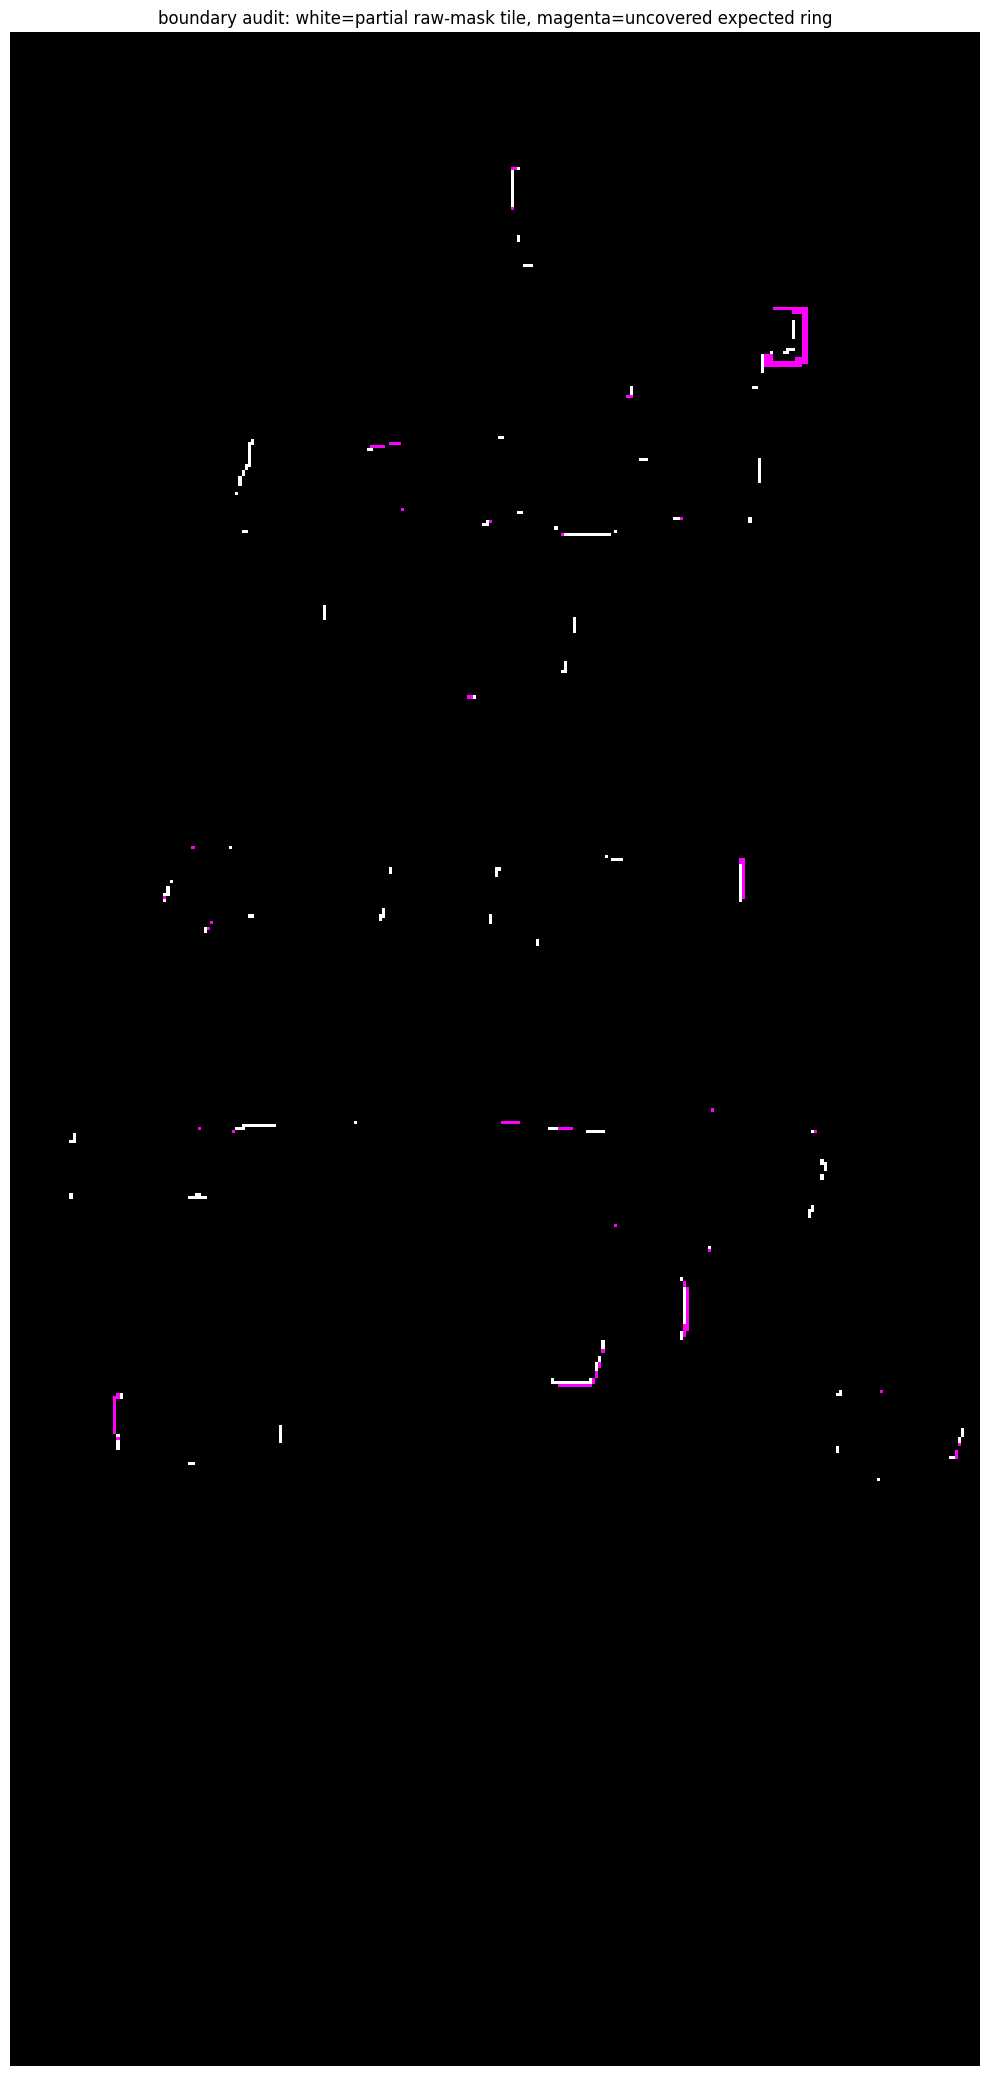

In [5]:
raw_coverage = manual_raw[:h_full, :w_full].reshape(
    n_ty, TILE, n_tx, TILE
).mean(axis=(1, 3))
partial_tiles = eligible_tile & (raw_coverage > 0) & (raw_coverage < 1)

manual_tile_all = manual[:h_full, :w_full].reshape(
    n_ty, TILE, n_tx, TILE
).all(axis=(1, 3))
train_seed = (ink_tile > 0) & manual_tile_all
train_exclusion = train_seed.astype(np.uint8)
if CLOSE_R > 0:
    train_exclusion = cv2.erode(
        cv2.dilate(train_exclusion, rect(CLOSE_R)), rect(CLOSE_R)
    ) & mask_tile
if GAP_R > 0:
    train_exclusion = cv2.dilate(train_exclusion, rect(GAP_R)) & mask_tile
expected_train_ring = (
    (cv2.dilate(train_exclusion, rect(SHELL_R)) - train_exclusion) > 0
) & (mask_tile > 0)
uncovered_train_ring = expected_train_ring & ~manual_tile_all

partial_coords = np.argwhere(partial_tiles)
uncovered_coords = np.argwhere(uncovered_train_ring)
expected_ring_count = int(expected_train_ring.sum())
uncovered_fraction = len(uncovered_coords) / max(expected_ring_count, 1)
print(f"eligible ring/ink tiles partially intersecting raw mask={len(partial_coords):,}")
print(
    f"expected training-ring tiles outside aligned train mask={len(uncovered_coords):,}/"
    f"{expected_ring_count:,} ({uncovered_fraction:.2%})"
)
print("first partial tile coordinates (y, x):", (partial_coords[:20] * TILE).tolist())
print("first uncovered ring coordinates (y, x):", (uncovered_coords[:20] * TILE).tolist())

boundary = np.zeros((n_ty, n_tx, 3), dtype=np.uint8)
boundary[partial_tiles] = [255, 255, 255]
boundary[uncovered_train_ring] = [255, 0, 255]
fig, ax = plt.subplots(figsize=(10, max(4, 10 * n_ty / n_tx)))
ax.imshow(boundary, interpolation="nearest")
ax.set_title("boundary audit: white=partial raw-mask tile, magenta=uncovered expected ring")
ax.axis("off")
plt.tight_layout()
plt.show()

## Full four-class center-target visualization

This figure shows only the supervised 8 px center targets. `pos_only=True` keeps actual ink targets and true ring-negative targets; non-ink cells inside positive base tiles and the closed-ring exclusion gap remain black.

saved /vesuvius/w013_campaign16_manual_split.png


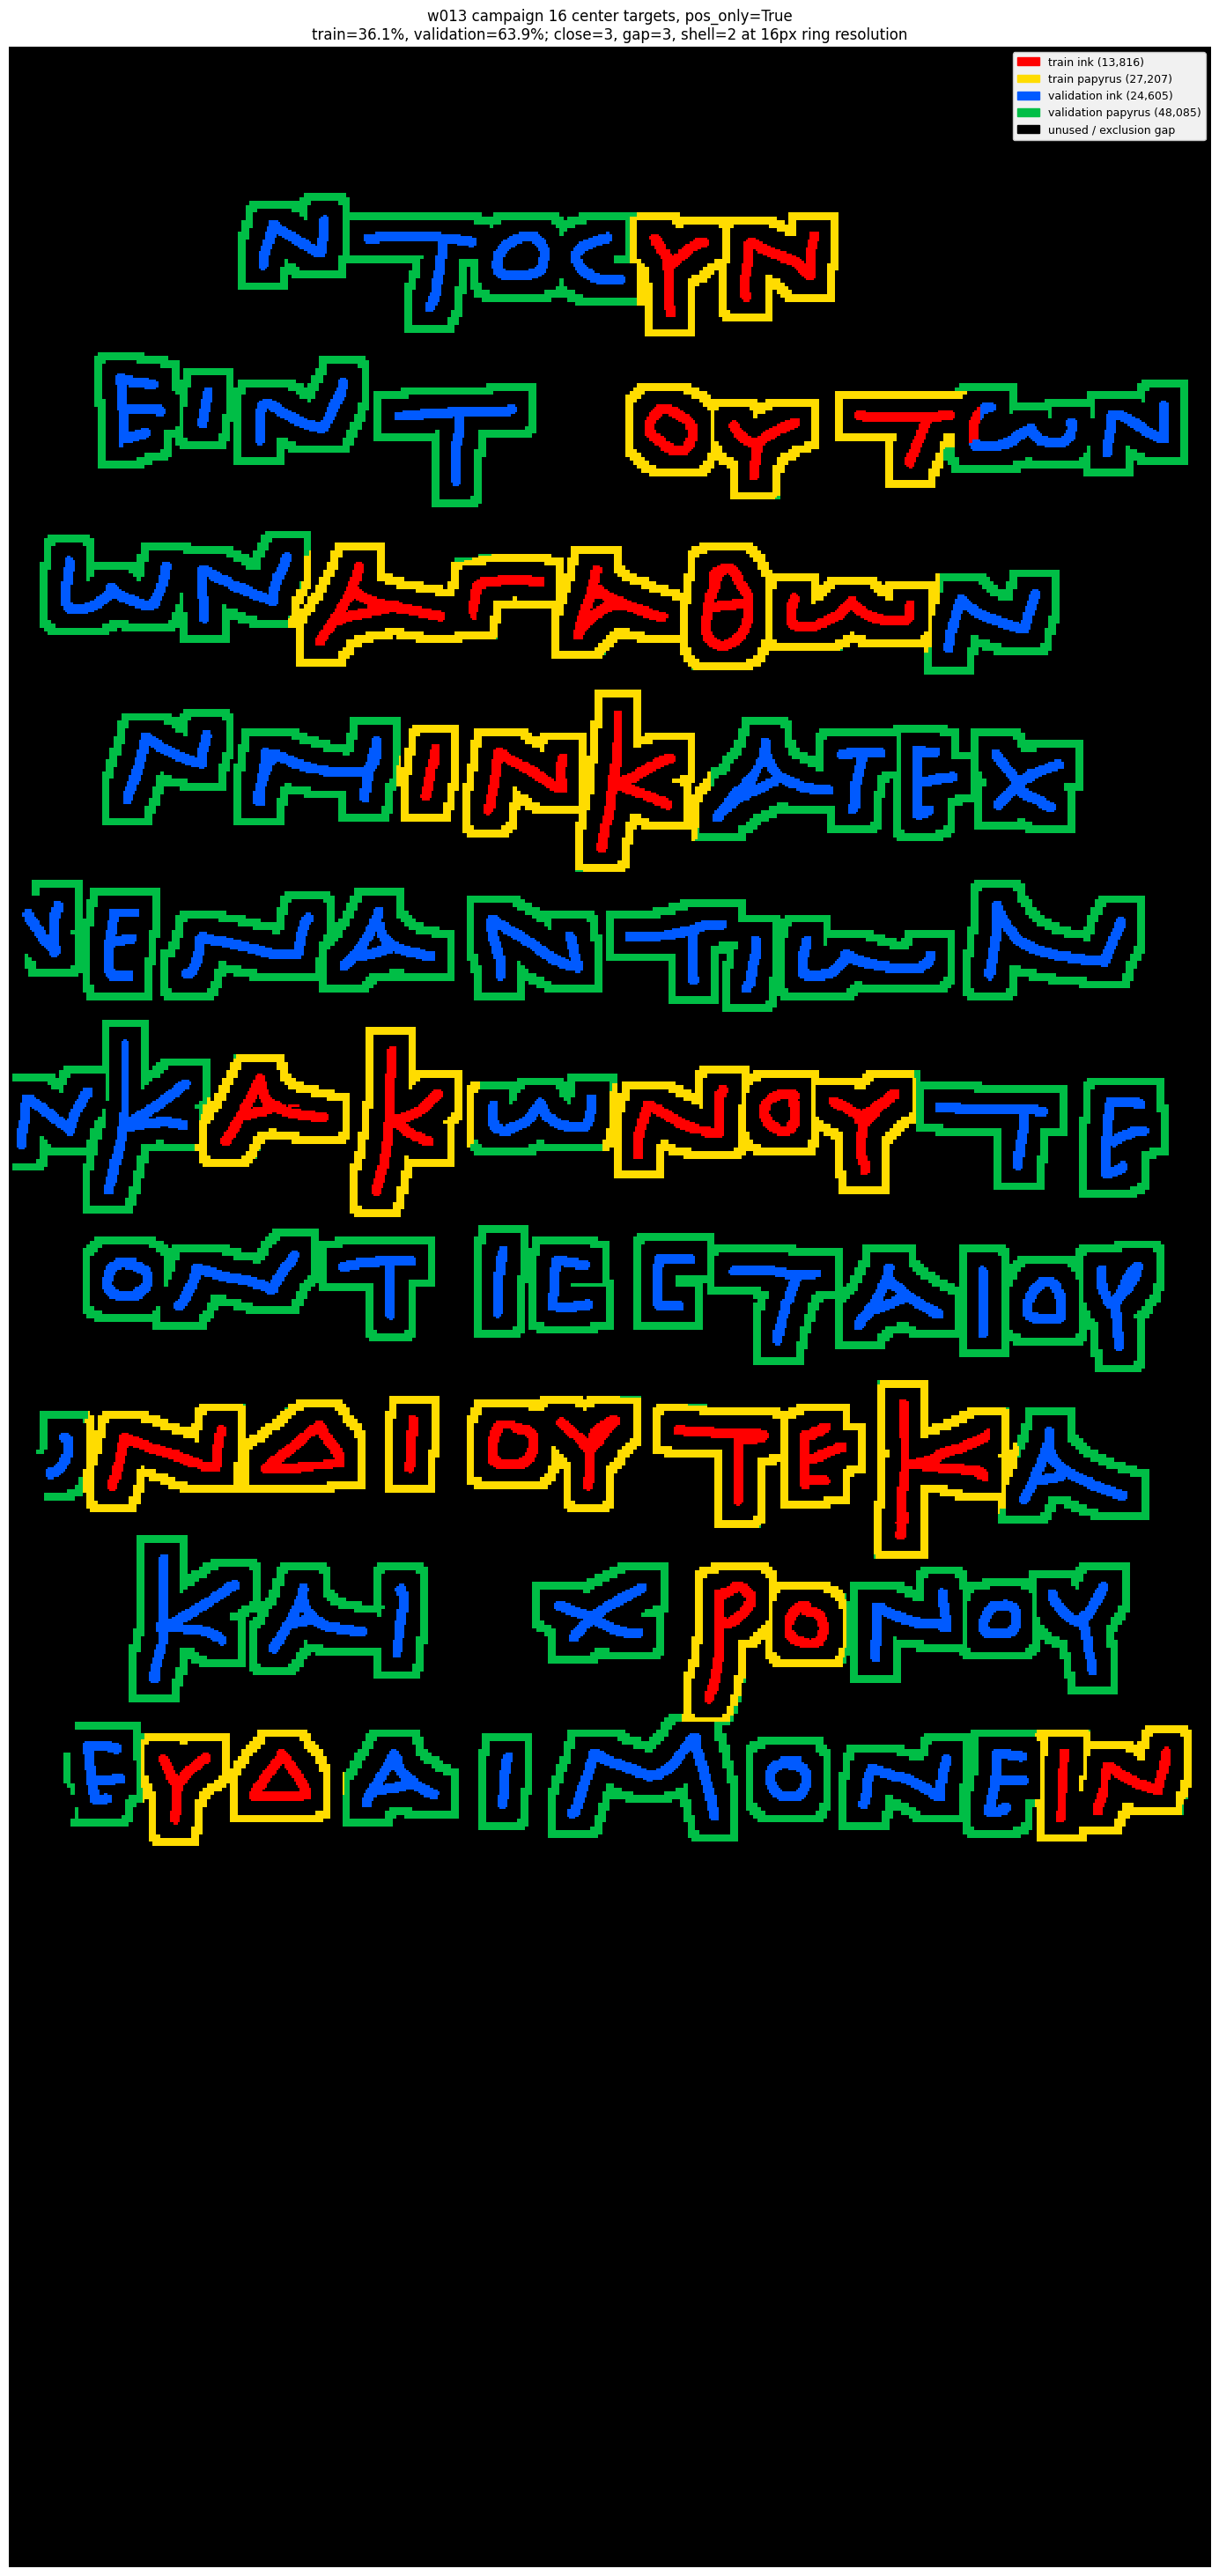

In [6]:
ring_unit = eligible_unit & ~ink_unit
ring_maps = {
    "train_ink": ink_unit & train_unit,
    "train_papyrus": ring_unit & train_unit,
    "valid_ink": ink_unit & ~train_unit,
    "valid_papyrus": ring_unit & ~train_unit,
}
ring_counts = {name: int(mask.sum()) for name, mask in ring_maps.items()}


def render_four_class(maps, title, out_name, count_values):
    rgb = np.zeros((n_uy, n_ux, 3), dtype=np.uint8)
    rgb[maps["train_ink"]] = [255, 0, 0]
    rgb[maps["train_papyrus"]] = [255, 220, 0]
    rgb[maps["valid_ink"]] = [0, 90, 255]
    rgb[maps["valid_papyrus"]] = [0, 190, 70]

    train_map = maps["train_ink"] | maps["train_papyrus"]
    valid_map = maps["valid_ink"] | maps["valid_papyrus"]
    train_fraction = train_map.sum() / max(train_map.sum() + valid_map.sum(), 1)
    fig, ax = plt.subplots(figsize=(14, max(5, 14 * n_uy / n_ux)))
    ax.imshow(rgb, interpolation="nearest")
    ax.set_title(
        f"{title}\ntrain={train_fraction:.1%}, validation={1 - train_fraction:.1%}; "
        f"close={CLOSE_R}, gap={GAP_R}, shell={SHELL_R} at {TILE}px ring resolution"
    )
    ax.axis("off")
    legend = [
        mpatches.Patch(color=(1, 0, 0), label=f"train ink ({count_values['train_ink']:,})"),
        mpatches.Patch(color=(1, 220 / 255, 0), label=f"train papyrus ({count_values['train_papyrus']:,})"),
        mpatches.Patch(color=(0, 90 / 255, 1), label=f"validation ink ({count_values['valid_ink']:,})"),
        mpatches.Patch(color=(0, 190 / 255, 70 / 255), label=f"validation papyrus ({count_values['valid_papyrus']:,})"),
        mpatches.Patch(color=(0, 0, 0), label="unused / exclusion gap"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=9, framealpha=0.95)
    plt.tight_layout()
    out_path = ROOT / out_name
    if SAVE_PNG:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()


render_four_class(
    ring_maps,
    f"w013 campaign 16 center targets, pos_only={POS_ONLY}",
    "w013_campaign16_manual_split.png",
    ring_counts,
)

## Compare legacy and manual split statistics

The legacy campaign-15 control uses w013's x-axis 75/25 split. This comparison uses the same 8 px target map as the manual audit.

In [7]:
legacy_split_x = (int(w_full * 0.75) // TILE) * TILE
legacy_train_cols = legacy_split_x // TARGET_UNIT
legacy_assignment = np.zeros((n_uy, n_ux), dtype=bool)
legacy_assignment[:, :legacy_train_cols] = True
legacy_maps, legacy_occurrences = simulate_multitile_split(legacy_assignment)


def split_stats(name, maps, occurrences):
    train_pos = int(maps["train_ink"].sum())
    train_neg = int(maps["train_papyrus"].sum())
    valid_pos = int(maps["valid_ink"].sum())
    valid_neg = int(maps["valid_papyrus"].sum())
    total_units = train_pos + train_neg + valid_pos + valid_neg
    train_occ = occurrences["train_ink"] + occurrences["train_papyrus"]
    valid_occ = occurrences["valid_ink"] + occurrences["valid_papyrus"]
    print(
        f"{name:8s} unique train={train_pos + train_neg:7,d} "
        f"({100 * (train_pos + train_neg) / max(total_units, 1):5.1f}%) "
        f"pos/neg={train_pos:,}/{train_neg:,}  "
        f"valid={valid_pos + valid_neg:7,d} pos/neg={valid_pos:,}/{valid_neg:,}"
    )
    print(f"         target occurrences train={train_occ:,} valid={valid_occ:,}")


split_stats("legacy", legacy_maps, legacy_occurrences)
split_stats("manual", manual_maps, manual_occurrences)

legacy   unique train= 89,905 ( 79.2%) pos/neg=30,322/59,583  valid= 23,596 pos/neg=8,056/15,540
         target occurrences train=359,620 valid=94,384
manual   unique train= 41,023 ( 36.1%) pos/neg=13,816/27,207  valid= 72,478 pos/neg=24,562/47,916
         target occurrences train=164,092 valid=289,912


## Campaign 15 parity and setup checks

These checks instantiate configurations only. They do not create a trainer or launch training. Expected metadata differences are removed before asserting that campaign 16's baseline matches campaign 15's `c32_t8` control.

In [8]:
from dataclasses import asdict
import sys
import types

try:
    import torch
except ModuleNotFoundError:
    torch = types.ModuleType("torch")
    torch.cuda = types.SimpleNamespace(
        is_available=lambda: False,
        empty_cache=lambda: None,
        synchronize=lambda: None,
    )
    sys.modules["torch"] = torch

import campaign_archs_15 as c15
import campaign_archs_16 as c16

control15 = next(test for test in c15.TESTS if test["tid"] == "c32_t8")
baseline16 = next(test for test in c16.TESTS if test["tid"] == "baseline")
manual16 = next(test for test in c16.TESTS if test["tid"] == "manual_split")

cfg15 = c15.build_config(control15)
cfg16 = c16.build_config(baseline16)

state15 = asdict(cfg15)
state16 = asdict(cfg16)
state15["exp_name"] = state16["exp_name"] = None
state15["tra"]["log_dir"] = state16["tra"]["log_dir"] = None
assert state15 == state16

baseline_payload = {
    k: v for k, v in baseline16.items() if k not in {"tid", "tag", "simple_split"}
}
manual_payload = {
    k: v for k, v in manual16.items() if k not in {"tid", "tag", "simple_split"}
}
assert baseline_payload == manual_payload
assert baseline16["simple_split"] is True
assert manual16["simple_split"] is False
assert len(c16.TESTS) == 2
assert cfg16.model.multitile_subtile == 8
assert cfg16.model.multitile_grid == 4
assert cfg16.data.multitile_train_step == 16
assert cfg16.data.multitile_pos_only is True
print("campaign 16 baseline config matches campaign 15 c32_t8")
print("manual arm differs only by simple_split")

for test in c16.TESTS:
    assert c16.run_test(c16.build_config(test), dry_run=True)
print("both campaign 16 dry-run setup paths completed")

AssertionError: 

## Campaign 16 commands

```bash
python campaign_archs_16.py --dry-run
python campaign_archs_16.py --only baseline
python campaign_archs_16.py --only manual_split
python campaign_archs_16.py
```

Outputs:

- TensorBoard runs: `runs_archs16/`
- Final checkpoints: `models/archs16/`
- Center-target split visualization: `w013_campaign16_manual_split.png`